Executing Phase 22 Multi-Class FDI (FDI1-FDI7) on: cuda
Input arrays loaded. X_train: (5011, 30, 12), X_test: (1052, 30, 12)

--- Multiclass Distribution (Train Split) ---
 Normal (Class 0)    : 3430 windows (68.45%)
 FDI1                :  226 windows (4.51%)
 FDI2                :  226 windows (4.51%)
 FDI3                :  226 windows (4.51%)
 FDI4                :  226 windows (4.51%)
 FDI5                :  226 windows (4.51%)
 FDI6                :  226 windows (4.51%)
 FDI7                :  225 windows (4.49%)


c:\Users\waliu\OneDrive\Documents\Code\Projects\Thesis\src\fdi_classifier.py:128: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path, map_

[SUCCESS] Loaded Pretrained SSL Encoder Backbone

--- Training Multi-Class FDI Classifier (20 Epochs) ---
Epoch [01/20] | Train Loss: 1.7698 | Val Loss: 1.7084 | Val Macro-F1: 28.51%
Epoch [05/20] | Train Loss: 0.8341 | Val Loss: 4.5805 | Val Macro-F1: 31.22%
Epoch [10/20] | Train Loss: 0.3808 | Val Loss: 9.8000 | Val Macro-F1: 32.28%
Epoch [15/20] | Train Loss: 0.2135 | Val Loss: 9.7588 | Val Macro-F1: 38.81%
Epoch [20/20] | Train Loss: 0.1527 | Val Loss: 10.3786 | Val Macro-F1: 34.22%

PHASE 22: MULTI-CLASS FDI1-FDI7 CLASSIFICATION REPORT
                 precision    recall  f1-score   support

         Normal     0.8537    0.0416    0.0793       842
   FDI1 (Scale)     0.0071    0.0333    0.0117        30
FDI2 (Flatline)     0.0000    0.0000    0.0000        30
    FDI3 (Ramp)     0.0370    1.0000    0.0713        30
    FDI4 (Drop)     1.0000    0.6333    0.7755        30
   FDI5 (Noise)     0.0000    0.0000    0.0000        30
 FDI6 (Inverse)     0.8750    0.2333    0.3684       

C:\Users\waliu\AppData\Local\Temp\ipykernel_70752\3527652425.py:181: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('../saved_models/fdi_mult

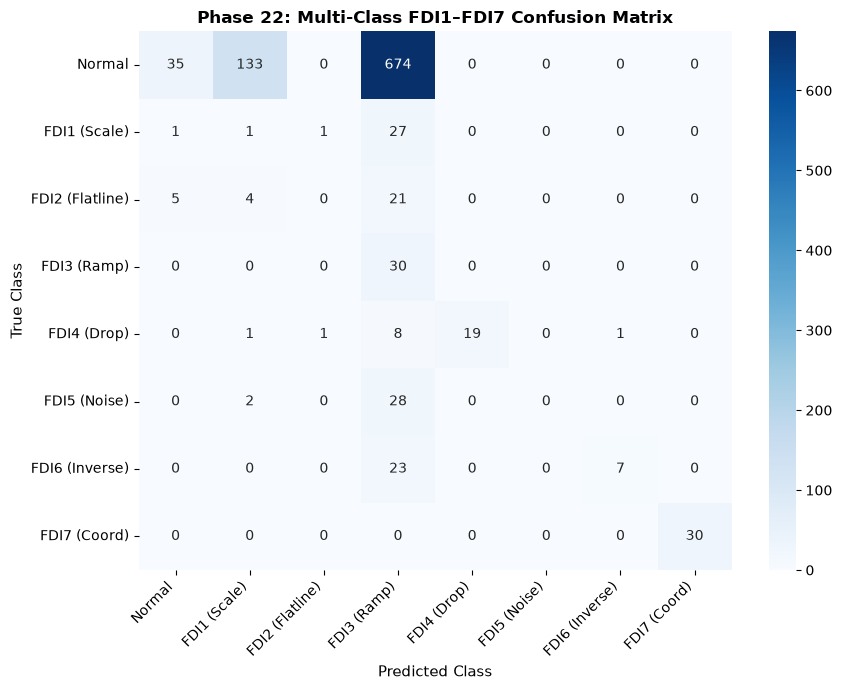

[COMPLETE] Phase 22 results and figures saved successfully.


In [1]:
# notebooks/20_phase22_multiclass_fdi.ipynb
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
from src.lstm_encoder import HybridCNNBiLSTMEncoder
from src.fdi_classifier import MultiClassTransferClassifier

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing Phase 22 Multi-Class FDI (FDI1-FDI7) on: {device}")

# -------------------------------------------------------------------------
# Step 1: Load Base Windows and Construct Controlled 8-Class Dataset
# -------------------------------------------------------------------------
data_path = Path('../data/processed_downstream/fdi_feeder_windows.npz')
assert data_path.exists(), f"Artifact missing at {data_path}"
data = np.load(data_path)

X_train_raw = data['X_train']  # (5011, 30, 12)
y_train_raw = data['y_train']  # binary
X_val_raw   = data['X_val']    # (1051, 30, 12)
y_val_raw   = data['y_val']
X_test_raw  = data['X_test']   # (1052, 30, 12)
y_test_raw  = data['y_test']

print(f"Input arrays loaded. X_train: {X_train_raw.shape}, X_test: {X_test_raw.shape}")

def inject_fdi_scenarios(X_arr, y_arr, seed=42):
    """
    Synthesizes exact Ahmad et al. FDI1-FDI7 signatures into attack windows
    while preserving clean normal windows as Class 0.
    """
    np.random.seed(seed)
    X_mod = X_arr.copy()
    y_multi = np.zeros(len(y_arr), dtype=np.int64)
    
    attack_indices = np.where(y_arr == 1)[0]
    num_attacks = len(attack_indices)
    
    # Evenly assign attack types 1 through 7 across attack windows
    assigned_types = np.array([(i % 7) + 1 for i in range(num_attacks)])
    np.random.shuffle(assigned_types)
    
    for idx, fdi_type in zip(attack_indices, assigned_types):
        y_multi[idx] = fdi_type
        win = X_mod[idx] # (30, 12)
        T, C = win.shape
        start = np.random.randint(5, 15)
        duration = np.random.randint(8, 15)
        end = min(start + duration, T)
        
        target_ch = np.random.choice(C, size=np.random.randint(1, 4), replace=False)
        
        if fdi_type == 1: # FDI1: Continuous Scaling
            alpha = np.random.choice([0.6, 0.75, 1.35, 1.5])
            win[start:end, target_ch] *= alpha
            
        elif fdi_type == 2: # FDI2: Flatline / Sensor Freeze
            win[start:end, target_ch] = win[start, target_ch]
            
        elif fdi_type == 3: # FDI3: Ramp Attack
            ramp = np.linspace(0, 0.5, end - start)[:, None]
            win[start:end, target_ch] += ramp
            
        elif fdi_type == 4: # FDI4: Dropout / Curtailment
            win[start:end, target_ch] *= 0.05
            
        elif fdi_type == 5: # FDI5: Gaussian Perturbation
            noise = np.random.normal(0, 0.25, size=(end - start, len(target_ch)))
            win[start:end, target_ch] += noise
            
        elif fdi_type == 6: # FDI6: Power / Waveform Inversion
            win[start:end, target_ch] = np.clip(1.0 - win[start:end, target_ch], 0.0, 1.0)
            
        elif fdi_type == 7: # FDI7: Coordinated Multi-Feeder Bias
            # System-wide current and frequency offset
            win[start:end, :] += 0.35
            
        X_mod[idx] = np.clip(win, 0.0, 1.0)
        
    return X_mod.astype(np.float32), y_multi

X_train_mc, y_train_mc = inject_fdi_scenarios(X_train_raw, y_train_raw, seed=42)
X_val_mc,   y_val_mc   = inject_fdi_scenarios(X_val_raw,   y_val_raw,   seed=101)
X_test_mc,  y_test_mc  = inject_fdi_scenarios(X_test_raw,  y_test_raw,  seed=202)

print("\n--- Multiclass Distribution (Train Split) ---")
for c in range(8):
    lbl = "Normal (Class 0)" if c == 0 else f"FDI{c}"
    cnt = np.sum(y_train_mc == c)
    print(f" {lbl:20s}: {cnt:4d} windows ({cnt/len(y_train_mc)*100:.2f}%)")

# -------------------------------------------------------------------------
# Step 2: Dataloaders & Class-Balanced Cross-Entropy Loss
# -------------------------------------------------------------------------
train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train_mc), torch.from_numpy(y_train_mc)), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(torch.from_numpy(X_val_mc),   torch.from_numpy(y_val_mc)),   batch_size=64, shuffle=False)
test_loader  = DataLoader(TensorDataset(torch.from_numpy(X_test_mc),  torch.from_numpy(y_test_mc)),  batch_size=64, shuffle=False)

# Compute inverse frequency weights
class_counts = np.bincount(y_train_mc, minlength=8)
class_weights = torch.tensor(len(y_train_mc) / (8.0 * class_counts), dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# -------------------------------------------------------------------------
# Step 3: Instantiate Model & Train
# -------------------------------------------------------------------------
model = MultiClassTransferClassifier(
    in_channels=12,
    pretrained_channels=25,
    num_classes=8,
    cnn_hidden_dims=(64, 128),
    lstm_hidden_dim=128,
    lstm_layers=2,
    mlp_hidden_dim=64,
    dropout=0.3,
    freeze_backbone=False
).to(device)

ssl_ckpt = Path('../saved_models/ssl_cnn_bilstm.pth')
if ssl_ckpt.exists():
    model.load_pretrained_backbone(str(ssl_ckpt), device)
    print("[SUCCESS] Loaded Pretrained SSL Encoder Backbone")

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

EPOCHS = 20
best_val_f1 = 0.0

print(f"\n--- Training Multi-Class FDI Classifier ({EPOCHS} Epochs) ---")
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        running_loss += loss.item() * len(xb)
        
    train_loss = running_loss / len(train_loader.dataset)
    
    model.eval()
    val_loss, preds_val, targets_val = 0.0, [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * len(xb)
            preds_val.extend(torch.argmax(logits, dim=1).cpu().numpy())
            targets_val.extend(yb.cpu().numpy())
            
    val_loss /= len(val_loader.dataset)
    val_macro_f1 = f1_score(targets_val, preds_val, average='macro', zero_division=0)
    scheduler.step(val_loss)
    
    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        torch.save(model.state_dict(), '../saved_models/fdi_multiclass_best.pth')
        
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Macro-F1: {val_macro_f1*100:.2f}%")

# -------------------------------------------------------------------------
# Step 4: Final Holdout Test Evaluation & Export Metrics
# -------------------------------------------------------------------------
model.load_state_dict(torch.load('../saved_models/fdi_multiclass_best.pth', map_location=device))
model.eval()

preds_test, targets_test = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds_test.extend(torch.argmax(logits, dim=1).cpu().numpy())
        targets_test.extend(yb.numpy())

class_names = ['Normal', 'FDI1 (Scale)', 'FDI2 (Flatline)', 'FDI3 (Ramp)', 
               'FDI4 (Drop)', 'FDI5 (Noise)', 'FDI6 (Inverse)', 'FDI7 (Coord)']

print("\n" + "="*70)
print("PHASE 22: MULTI-CLASS FDI1-FDI7 CLASSIFICATION REPORT")
print("="*70)
print(classification_report(targets_test, preds_test, target_names=class_names, digits=4, zero_division=0))
print("="*70)

# Save metrics CSV
report_dict = classification_report(targets_test, preds_test, target_names=class_names, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report_dict).transpose()
results_dir = Path('../results')
results_dir.mkdir(parents=True, exist_ok=True)
df_report.to_csv(results_dir / 'phase22_multiclass_fdi_results.csv')

# Plot Confusion Matrix
cm = confusion_matrix(targets_test, preds_test)
fig_dir = Path('../results/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Phase 22: Multi-Class FDI1–FDI7 Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=11)
plt.ylabel('True Class', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(fig_dir / 'phase22_multiclass_confusion_matrix.png', dpi=300)
plt.show()
print("[COMPLETE] Phase 22 results and figures saved successfully.")